In [55]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import utilities  ### Created function to generate the descriptors 
from utilities import calculate_rdkit_features
from utilities import calculate_rdkit_features1
from utilities import calculate_aromatic_proportion

In [2]:
import pandas as pd 
train_set=pd.read_csv('/Users/mushtaqali/Desktop/Solubility /Solubility_Paper/data/final_unique_train.csv')
SMILES_train=train_set.smiles_canon
combined_df=utilities.create_feature_multiple(SMILES_train)

[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:15] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not removing hydrogen atom without neighbors
[00:16:16] WARNING: not r

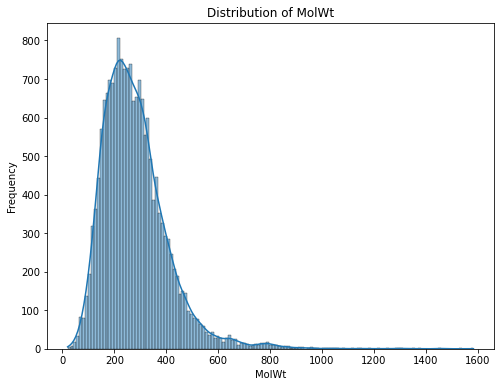

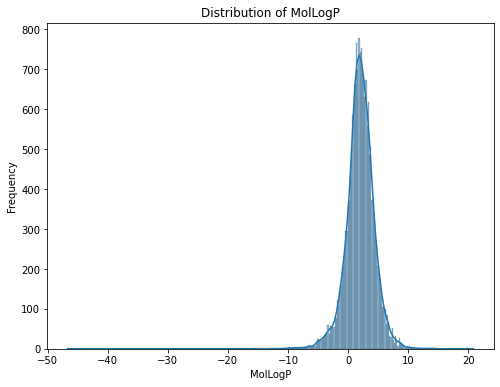

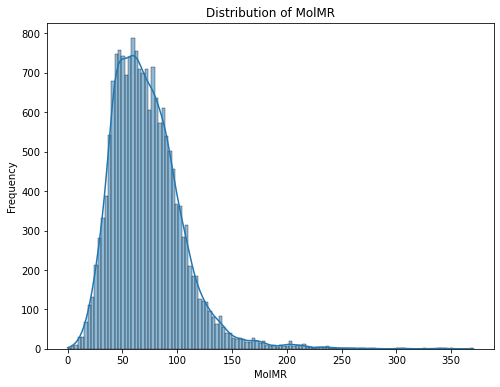

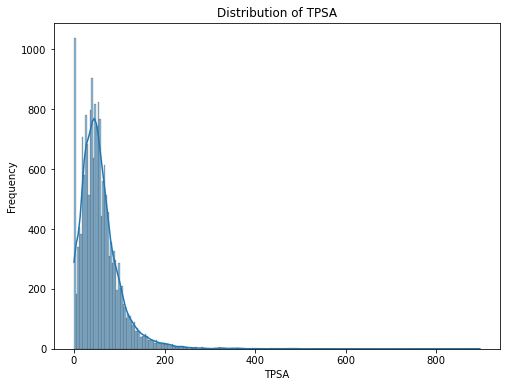

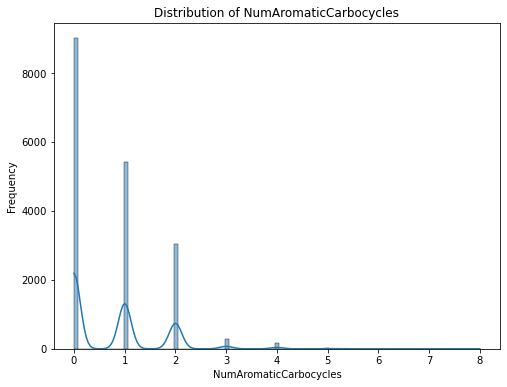

In [56]:
### Visualize the range of reference features data on traning set 
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your training data in a pandas DataFrame called `training_data`
features_to_plot = ["MolWt", "MolLogP", "MolMR", "TPSA", "NumAromaticCarbocycles"]

# Plotting the distribution of each feature
for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.histplot(combined_df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()


📏 Mahalanobis Distance of new molecule: 22.011
🔺 95th percentile threshold: 20.296

📋 Reference Feature Summary (not used for AD decision):
MolWt: 588.562 (95% range: 102.133 – 589.126)
MolLogP: 1.339 (95% range: -3.108 – 6.523)
MolMR: 138.345 (95% range: 25.445 – 145.571)
TPSA: 160.830 (95% range: 0.000 – 167.302)
NumAromaticCarbocycles: 2.000 (95% range: 0.000 – 3.000)

❌ New molecule is OUTSIDE the Applicability Domain (based on 298 features).


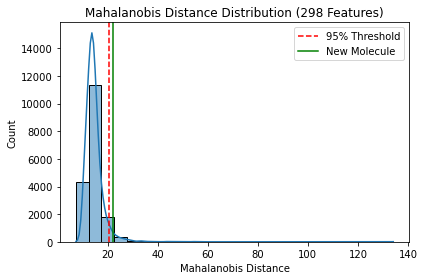

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis

# SMILES of the compound to test
### Molecular weight 588.6g/mol  
SMILES = '[C@H]1(C5=C([C@H](C2[C@@H]1C(OC2)=O)O[C@@H]3O[C@H]4[C@H]([C@@H]([C@H]3O)O)O[C@@H](OC4)C)C=C6C(=C5)OCO6)C7=CC(=C(C(=C7)OC)O)OC'

# Selected features for reference only (not for AD decision)
selected_features = ["MolWt", "MolLogP", "MolMR", "TPSA", "NumAromaticCarbocycles"]

# 1. Generate features for the new molecule
single_df = utilities.create_feature_single(SMILES)

# 2. Select all 298 features (numeric only) for Mahalanobis
combined_df_numeric = combined_df.select_dtypes(include=[np.number])
single_df_numeric = single_df[combined_df_numeric.columns]

# Concatenate and clean NaNs/Infs
combined_all = pd.concat([combined_df_numeric, single_df_numeric], axis=0)
combined_all_clean = combined_all.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# Split back into training and test
training_features = combined_all_clean.iloc[:-1].values
new_features = combined_all_clean.iloc[-1:].values



# 3. Standardize and compute Mahalanobis distance
scaler = StandardScaler()
training_scaled = scaler.fit_transform(training_features)
new_scaled = scaler.transform(new_features)

cov_matrix = LedoitWolf().fit(training_scaled).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vector = np.mean(training_scaled, axis=0)

# Distances
mahal_distances = [mahalanobis(x, mean_vector, inv_cov_matrix) for x in training_scaled]
new_distance = mahalanobis(new_scaled.flatten(), mean_vector, inv_cov_matrix)
mahal_threshold = np.percentile(mahal_distances, 95)

# 4. Print Mahalanobis result
print(f"\n📏 Mahalanobis Distance of new molecule: {new_distance:.3f}")
print(f"🔺 95th percentile threshold: {mahal_threshold:.3f}")

# 5. Feature-wise reference check (not for decision)
print("\n📋 Reference Feature Summary (not used for AD decision):")
for feature in selected_features:
    if feature in combined_df.columns and feature in single_df.columns:
        lower = np.percentile(combined_df[feature].dropna(), 2.5)
        upper = np.percentile(combined_df[feature].dropna(), 97.5)
        value = single_df[feature].values[0]
        print(f"{feature}: {value:.3f} (95% range: {lower:.3f} – {upper:.3f})")
    else:
        print(f"{feature}: ⚠️ Not available in dataset")

# 6. Final AD decision
if new_distance <= mahal_threshold:
    print("\n✅ New molecule is WITHIN the Applicability Domain (based on 298 features).")
else:
    print("\n❌ New molecule is OUTSIDE the Applicability Domain (based on 298 features).")

# 7. Plot Mahalanobis distribution
sns.histplot(mahal_distances, bins=25, kde=True)
plt.axvline(mahal_threshold, color='red', linestyle='--', label='95% Threshold')
plt.axvline(new_distance, color='green', linestyle='-', label='New Molecule')
plt.title("Mahalanobis Distance Distribution (298 Features)")
plt.savefig('mahalanobis_distance_new2.png', dpi=300,transparent=True)
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()



📏 Mahalanobis Distance of new molecule: 17.815
🔺 95th percentile threshold: 20.296

📋 Reference Feature Summary (not used for AD decision):
MolWt: 438.299 (95% range: 102.133 – 589.126)
MolLogP: 2.881 (95% range: -3.108 – 6.523)
MolMR: 100.291 (95% range: 25.445 – 145.571)
TPSA: 83.910 (95% range: 0.000 – 167.302)
NumAromaticCarbocycles: 1.000 (95% range: 0.000 – 3.000)

✅ New molecule is WITHIN the Applicability Domain (based on 298 features).


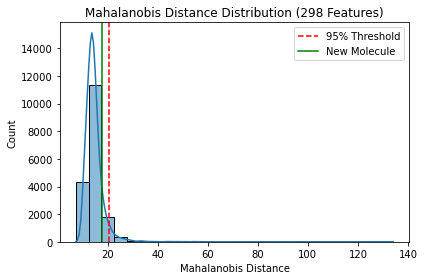

In [63]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis

# SMILES of the compound to test
### Molecular weight 588.6g/mol  
SMILES = 'CCOC(=O)CN1C2=CC=CC=C2C(C1=O)(CC(=O)C3=CC=C(S3)Br)O'

# Selected features for reference only (not for AD decision)
selected_features = ["MolWt", "MolLogP", "MolMR", "TPSA", "NumAromaticCarbocycles"]

# 1. Generate features for the new molecule
single_df = utilities.create_feature_single(SMILES)

# 2. Select all 298 features (numeric only) for Mahalanobis
combined_df_numeric = combined_df.select_dtypes(include=[np.number])
single_df_numeric = single_df[combined_df_numeric.columns]

# Concatenate and clean NaNs/Infs
combined_all = pd.concat([combined_df_numeric, single_df_numeric], axis=0)
combined_all_clean = combined_all.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# Split back into training and test
training_features = combined_all_clean.iloc[:-1].values
new_features = combined_all_clean.iloc[-1:].values


# 3. Standardize and compute Mahalanobis distance
scaler = StandardScaler()
training_scaled = scaler.fit_transform(training_features)
new_scaled = scaler.transform(new_features)

cov_matrix = LedoitWolf().fit(training_scaled).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vector = np.mean(training_scaled, axis=0)

# Distances
mahal_distances = [mahalanobis(x, mean_vector, inv_cov_matrix) for x in training_scaled]
new_distance = mahalanobis(new_scaled.flatten(), mean_vector, inv_cov_matrix)
mahal_threshold = np.percentile(mahal_distances, 95)

# 4. Print Mahalanobis result
print(f"\n📏 Mahalanobis Distance of new molecule: {new_distance:.3f}")
print(f"🔺 95th percentile threshold: {mahal_threshold:.3f}")

# 5. Feature-wise reference check (not for decision)
print("\n📋 Reference Feature Summary (not used for AD decision):")
for feature in selected_features:
    if feature in combined_df.columns and feature in single_df.columns:
        lower = np.percentile(combined_df[feature].dropna(), 2.5)
        upper = np.percentile(combined_df[feature].dropna(), 97.5)
        value = single_df[feature].values[0]
        print(f"{feature}: {value:.3f} (95% range: {lower:.3f} – {upper:.3f})")
    else:
        print(f"{feature}: ⚠️ Not available in dataset")

# 6. Final AD decision
if new_distance <= mahal_threshold:
    print("\n✅ New molecule is WITHIN the Applicability Domain (based on 298 features).")
else:
    print("\n❌ New molecule is OUTSIDE the Applicability Domain (based on 298 features).")

# 7. Plot Mahalanobis distribution
sns.histplot(mahal_distances, bins=25, kde=True)
plt.axvline(mahal_threshold, color='red', linestyle='--', label='95% Threshold')
plt.axvline(new_distance, color='green', linestyle='-', label='New Molecule')
plt.title("Mahalanobis Distance Distribution (298 Features)")
plt.xlabel("Mahalanobis Distance")
plt.savefig('mahalanobis_distance_new1.png', dpi=300,transparent=True)
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
